Importing the required libraries

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector

Building the QFT circuit for 3 qubits

In [2]:
def qft_3(circuit, qubits):
    n = len(qubits)
    # Apply Hadamard and controlled phases
    for i in range(n):
        circuit.h(qubits[i])
        for j in range(i+1, n):
            # Controlled phase: angle = pi / 2^(j-i)
            circuit.cp(3.14159 / (2 ** (j - i)), qubits[j], qubits[i])
    # Swap qubits to reverse order
    for i in range(n//2):
        circuit.swap(qubits[i], qubits[n-1-i])

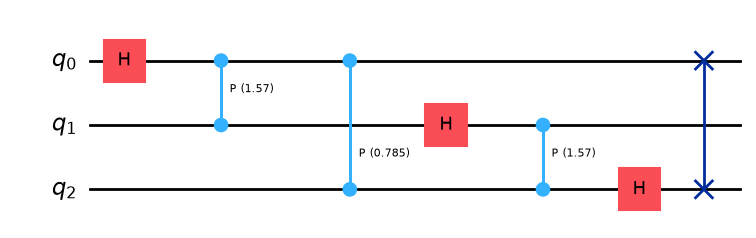

In [3]:
qc = QuantumCircuit(3)
qft_3(qc, [0, 1, 2])
qc.draw('mpl')

Simulating the QFT and verifying the output

In [4]:
# Append statevector saving
qc.save_statevector()

# Run on the Aer simulator
sim = AerSimulator()
job = sim.run(qc)
result = job.result()

# Get the statevector
statevector = result.get_statevector(qc)
print("Amplitudes for |000> input:")
print(statevector)

Amplitudes for |000> input:
Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))


Testing with a different input state

In [5]:
qc2 = QuantumCircuit(3)
qc2.x(0)   # set qubit 0 to |1>
qft_3(qc2, [0, 1, 2])
qc2.save_statevector()

job2 = sim.run(qc2)
state2 = job2.result().get_statevector(qc2)
print("Amplitudes for |001> input:")
print(state2)

Amplitudes for |001> input:
Statevector([ 0.35355339-4.32978028e-17j,  0.35355339-4.32978028e-17j,
              0.35355339-4.32978028e-17j,  0.35355339-4.32978028e-17j,
             -0.35355339+4.32978028e-17j, -0.35355339+4.32978028e-17j,
             -0.35355339+4.32978028e-17j, -0.35355339+4.32978028e-17j],
            dims=(2, 2, 2))
